# Optimización del Reemplazo de Flotas de Autobuses Diésel por Eléctricos en Quito: Un Enfoque de Programación Lineal Entera Mixta

## Implementación y Análisis Computacional

### Estéfano Viteri - Luis Miguel Torres
### 

## Introducción

Este cuaderno de Jupyter presenta la implementación del modelo de optimización para el reemplazo de flotas de autobuses diésel por eléctricos en la ciudad de Quito. El objetivo principal es analizar diferentes escenarios y evaluar la viabilidad económica y ambiental del plan de transición.

## Implementación

In [1]:
from modulo_input_modelo import crear_input, Transicion_flota_modelo, tam_bat
import pandas as pd

In [2]:
# Lectura de parámetros iniciales, estado de la flota actual y su operación
datos = pd.read_excel('input_EPMTPQ.xlsx',sheet_name=None)

# Definición del Caso Base
params = {'fin_horizonte': True, 'presupuesto': [False,12000000], 'emisiones': True, 'contenedores': True, 'edad_media': True,
          'reduccion_anual_precio_bateria': 0.12, 'Precio_Elect_Noche': 0.073, 'Precio_Elect_Dia': 0.084,
          'rho_N': 0.75, 'Precio_diesel': 0.44, 'Periodos': 26, 'Tasa_redu_emisiones': 1/26,'mantenimiento_elec_ahorro': 6/10,
          'escenario': 0} # Caso Base

params_exp = params
L,CT,T,K,J_K,J_K_tilde,K_E,C,alpha,R,beta,f,s,kappa,mc,p,F,g,p_tilde,num_per,o,q,h,t1,a,e,e_tilde,t_F,Gamma,theta,theta_tilde,B,Theta,Theta_tilde,var_epsilon,c_tilde,costo_kwh,cost_bus_sin_bat = crear_input(datos,params_exp)

Costo de baterias Schmidt


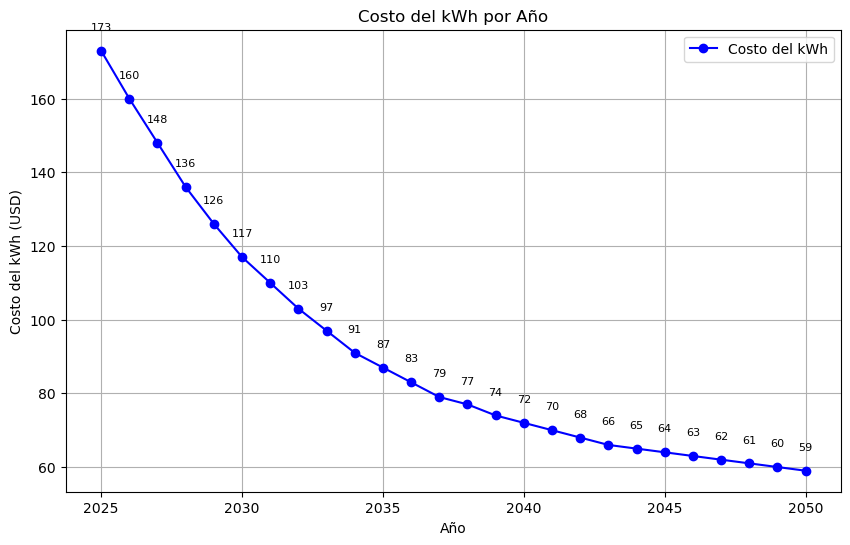

In [3]:
import matplotlib.pyplot as plt

# Ajustar los valores de los años y costos para que se vean mejor
años = list(costo_kwh.keys())
costos = [round(costo) for costo in costo_kwh.values()]  # Redondear los costos para quitar los decimales

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(años, costos, marker='o', linestyle='-', color='blue', label='Costo del kWh')

# Configurar el gráfico
plt.title('Costo del kWh por Año')
plt.xlabel('Año')
plt.ylabel('Costo del kWh (USD)')
plt.grid(True)
plt.legend()

# Añadir los valores de cada punto en la gráfica con mayor separación
for año, costo in zip(años, costos):
    plt.text(año, costo + 5, f'{costo}', fontsize=8, ha='center', va='bottom')  # Ajustar la posición del texto

plt.show()


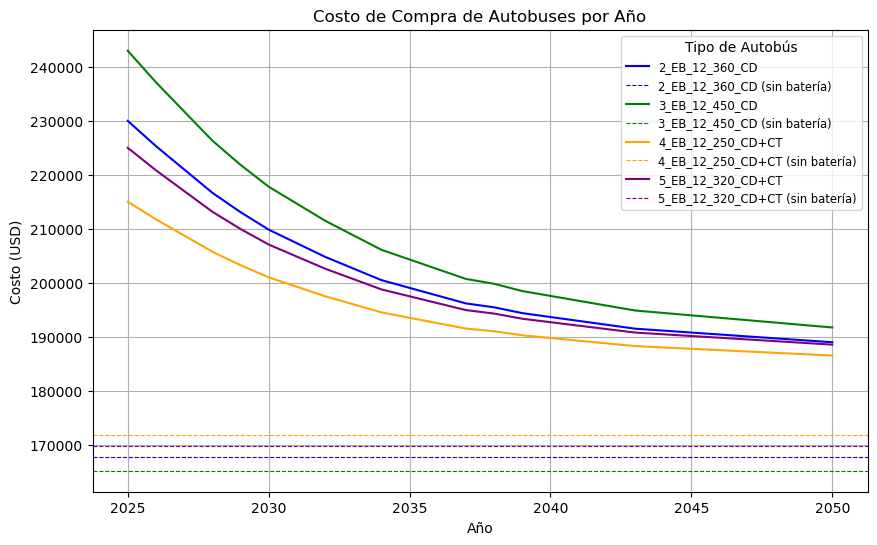

In [4]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Crear un diccionario para organizar los datos por tipo de autobús
costos_por_tipo = {}
for (k, t), costo in f.items():
    if k not in costos_por_tipo:
        costos_por_tipo[k] = {}
    costos_por_tipo[k][t] = costo

# Crear el gráfico
plt.figure(figsize=(10, 6))
# Definir una lista de colores personalizados o usar el colormap por defecto
custom_colors = ['red', 'blue', 'green', 'orange', 'purple']  # Puedes personalizar esta lista
colors = lambda idx: custom_colors[idx % len(custom_colors)]  # Asignar colores de la lista
for idx, (k, costos) in enumerate(costos_por_tipo.items()):
    if 'Diesel' not in k:
        años = sorted(costos.keys())
        valores = [costos[año] for año in años]
        color = colors(idx)  # Asignar un color único por tipo de autobús
        plt.plot(años, valores, label=k, color=color)
        # Añadir línea horizontal para el costo sin batería con el mismo color
        plt.axhline(y=cost_bus_sin_bat[k], linestyle='--', linewidth=0.8, label=f'{k} (sin batería)', color=color)

# Configurar el gráfico
plt.title('Costo de Compra de Autobuses por Año')
plt.xlabel('Año')
plt.ylabel('Costo (USD)')
plt.legend(title='Tipo de Autobús', loc='upper right', fontsize='small')
plt.grid(True)
plt.show()

In [5]:
L,CT,T,K,J_K,J_K_tilde,K_E,C,alpha,R,beta,f,s,kappa,mc,p,F,g,p_tilde,num_per,o,q,h,t1,a,e,e_tilde,t_F,Gamma,theta,theta_tilde,B,Theta,Theta_tilde,var_epsilon,c_tilde,costo_kwh,cost_bus_sin_bat = crear_input(datos,params)

Costo de baterias Schmidt


In [6]:
sol_CB = {}

mo,x,y,z,w,u,v,b,u_tilde,v_tilde,sol_salida = Transicion_flota_modelo(L,CT,T,K,J_K,J_K_tilde,K_E,C,alpha,R,beta,f,s,kappa,mc,p,F,g,p_tilde,num_per,o,q,h,t1,a,e,e_tilde,t_F,Gamma,theta,theta_tilde,B,Theta,var_epsilon,c_tilde,sol_CB,params_exp)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-03-19
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-9700K CPU @ 3.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
MIPGap  0

Optimize a model with 22465 rows, 22204 columns and 93622 nonzeros
Model fingerprint: 0x0e36972c
Variable types: 26 continuous, 22178 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-02, 1e+06]
  Objective range  [1e+03, 8e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+07]
Presolve removed 18950 rows and 8045 columns
Presolve time: 0.07s
Presolved: 3515 rows, 14159 columns, 35212 nonzeros
Variable types: 0 continuous, 14159 integer (72 binary)

Root relaxation: objective 4.336222e+07, 20567 iterations, 0.36 seconds (

In [7]:
from modulo_exportacion import exportar_solucion
informacion = {}

info_exportar = exportar_solucion(x,z,y,u,u_tilde,v,v_tilde,w,b,K,T,J_K,CT,R,f,p,o,F,g,mo,kappa,alpha,beta,num_per,p_tilde,K_E,J_K_tilde,t_F,s,mc,var_epsilon,Theta,Theta_tilde,L,params_exp)
informacion['Escenario 0'] = info_exportar


c:\Users\PC01\Documents\tesis_master_opti\modulo_exportacion.py:96: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  j.to_excel(writer, i)


In [18]:
import numpy as np
def graficar_sensibilidad_variable_v14(modelo, variable_dict, nombre_var: str, eje_tiempo_idx: int = 1):
    """
    Versión 14: Mejora el espacio visual para los símbolos ∞, asegurando separación suficiente del eje.
    """
    data_por_tipo = {}
    rangos = {}

    for idx, var in variable_dict.items():
        try:
            sa_low = var.SAObjLow
            sa_up = var.SAObjUp
            obj_coef = var.Obj
            rangos[idx] = [(sa_low, sa_up) , obj_coef]
            if isinstance(idx, tuple):
                tipo = idx[0]
                tiempo = idx[eje_tiempo_idx]
            else:
                tipo = 'default'
                tiempo = idx
            if tipo not in data_por_tipo:
                data_por_tipo[tipo] = []
            data_por_tipo[tipo].append((tiempo, sa_low, obj_coef, sa_up))
        except AttributeError:
            continue

    n_tipos = len(data_por_tipo)
    if n_tipos == 0:
        print(f"No hay datos de sensibilidad disponibles para '{nombre_var}'. ¿Es un modelo LP?")
        return

    fig, axs = plt.subplots(n_tipos, 1, figsize=(14, 4 * n_tipos), sharex=True)
    if n_tipos == 1:
        axs = [axs]

    bar_width = 0.4
    marker_width = 0.25

    for ax, (tipo, data) in zip(axs, sorted(data_por_tipo.items())):
        data.sort(key=lambda x: x[0])
        tiempo, low, obj, up = zip(*data)

        low_vals = [l for l in low if np.isfinite(l)]
        up_vals = [u for u in up if np.isfinite(u)]
        all_vals = list(obj) + low_vals + up_vals

        y_min_data = min(all_vals) if all_vals else 0
        y_max_data = max(all_vals) if all_vals else 1
        range_span = y_max_data - y_min_data if y_max_data != y_min_data else 1

        # Ampliar más para separar ∞ del tope visual
        y_inf_up = y_max_data + 0.12 * range_span
        y_inf_low = y_min_data - 0.12 * range_span
        y_max = y_inf_up + 0.08 * range_span
        y_min = y_inf_low - 0.08 * range_span

        for t, l, o_, u_ in zip(tiempo, low, obj, up):
            l_draw = y_inf_low if not np.isfinite(l) else l
            u_draw = y_inf_up if not np.isfinite(u_) else u_
            alto = u_draw - l_draw

            ax.add_patch(plt.Rectangle((t - bar_width / 2, l_draw), bar_width, alto,
                                       facecolor='skyblue', alpha=0.4, edgecolor=None, zorder=1))

            if np.isfinite(l):
                ax.plot([t - bar_width / 2, t + bar_width / 2], [l, l], color='red', linewidth=2.5, zorder=2)
            else:
                ax.plot([t - bar_width / 4, t + bar_width / 4], [y_inf_low, y_inf_low],
                        color='red', linewidth=2.5, zorder=2)
                ax.text(t, y_inf_low - 0.015 * range_span, '∞', color='red', fontsize=12,
                        ha='center', va='top')

            if np.isfinite(u_):
                ax.plot([t - bar_width / 2, t + bar_width / 2], [u_, u_], color='red', linewidth=2.5, zorder=2)
            else:
                ax.plot([t - bar_width / 4, t + bar_width / 4], [y_inf_up, y_inf_up],
                        color='red', linewidth=2.5, zorder=2)
                ax.text(t, y_inf_up + 0.015 * range_span, '∞', color='red', fontsize=12,
                        ha='center', va='bottom')

            ax.plot([t - marker_width / 2, t + marker_width / 2], [o_, o_],
                    color='black', linewidth=2.5, zorder=3)

        ax.set_title(f"{nombre_var} - Tipo: {tipo}", fontsize=14)
        ax.set_ylabel("Valor coeficiente", fontsize=11)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, linestyle='--', alpha=0.5)

    axs[-1].set_xlabel("Año", fontsize=12)
    plt.tight_layout()
    plt.show()
    return rangos

def graficar_sensibilidad_costo_kwh(dict_info, nombre_var: str, eje_tiempo_idx: int = 1,porcen = False):
    data_por_tipo = {}
    rangos = {}

    for idx, var in dict_info.items():
        try:
            sa_low = var[0][0] if porcen == False else var[0][0] / var[1]
            sa_up = var[0][1] if porcen == False else var[0][1] / var[1]
            obj_coef = var[1] if porcen == False else 1
            if isinstance(idx, tuple):
                tipo = idx[0]
                tiempo = idx[eje_tiempo_idx]
            else:
                tipo = 'default'
                tiempo = idx
            if tipo not in data_por_tipo:
                data_por_tipo[tipo] = []
            data_por_tipo[tipo].append((tiempo, sa_low, obj_coef, sa_up))
        except AttributeError:
            continue

    n_tipos = len(data_por_tipo)
    if n_tipos == 0:
        print(f"No hay datos de sensibilidad disponibles para '{nombre_var}'. ¿Es un modelo LP?")
        return

    fig, axs = plt.subplots(n_tipos, 1, figsize=(14, 4 * n_tipos), sharex=True)
    if n_tipos == 1:
        axs = [axs]

    bar_width = 0.4
    marker_width = 0.25

    for ax, (tipo, data) in zip(axs, sorted(data_por_tipo.items())):
        data.sort(key=lambda x: x[0])
        tiempo, low, obj, up = zip(*data)

        low_vals = [l for l in low if np.isfinite(l)]
        up_vals = [u for u in up if np.isfinite(u)]
        all_vals = list(obj) + low_vals + up_vals

        y_min_data = min(all_vals) if all_vals else 0
        y_max_data = max(all_vals) if all_vals else 1
        range_span = y_max_data - y_min_data if y_max_data != y_min_data else 1

        # Ampliar más para separar ∞ del tope visual
        y_inf_up = y_max_data + 0.12 * range_span
        y_inf_low = y_min_data - 0.12 * range_span
        y_max = y_inf_up + 0.08 * range_span
        y_min = y_inf_low - 0.08 * range_span

        for t, l, o_, u_ in zip(tiempo, low, obj, up):
            l_draw = y_inf_low if not np.isfinite(l) else l
            u_draw = y_inf_up if not np.isfinite(u_) else u_
            alto = u_draw - l_draw

            ax.add_patch(plt.Rectangle((t - bar_width / 2, l_draw), bar_width, alto,
                                       facecolor='skyblue', alpha=0.4, edgecolor=None, zorder=1))

            if np.isfinite(l):
                ax.plot([t - bar_width / 2, t + bar_width / 2], [l, l], color='red', linewidth=2.5, zorder=2)
            else:
                ax.plot([t - bar_width / 4, t + bar_width / 4], [y_inf_low, y_inf_low],
                        color='red', linewidth=2.5, zorder=2)
                ax.text(t, y_inf_low - 0.015 * range_span, '∞', color='red', fontsize=12,
                        ha='center', va='top')

            if np.isfinite(u_):
                ax.plot([t - bar_width / 2, t + bar_width / 2], [u_, u_], color='red', linewidth=2.5, zorder=2)
            else:
                ax.plot([t - bar_width / 4, t + bar_width / 4], [y_inf_up, y_inf_up],
                        color='red', linewidth=2.5, zorder=2)
                ax.text(t, y_inf_up + 0.015 * range_span, '∞', color='red', fontsize=12,
                        ha='center', va='bottom')

            ax.plot([t - marker_width / 2, t + marker_width / 2], [o_, o_],
                    color='black', linewidth=2.5, zorder=3)

        ax.set_title(f"{nombre_var} - Tipo: {tipo}", fontsize=14)
        ax.set_ylabel("Valor coeficiente", fontsize=11)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, linestyle='--', alpha=0.5)

    axs[-1].set_xlabel("Año", fontsize=12)
    plt.tight_layout()
    plt.show()
    return rangos


Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-9700K CPU @ 3.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
MIPGap  0

Optimize a model with 22465 rows, 22204 columns and 93622 nonzeros
Model fingerprint: 0x216daf52
Coefficient statistics:
  Matrix range     [5e-02, 1e+06]
  Objective range  [1e+03, 8e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+07]
Presolve removed 8206 rows and 8024 columns
Presolve time: 0.08s
Presolved: 14259 rows, 14180 columns, 71178 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.04s

Barrier statistics:
 AA' NZ     : 1.239e+05
 Factor NZ  : 3.093e+05 (roughly 14 MB of memory)
 Factor Ops : 1.531e+07 (less than 1 second per iteration)
 Threads    : 6

                  Objective                Residual
Iter

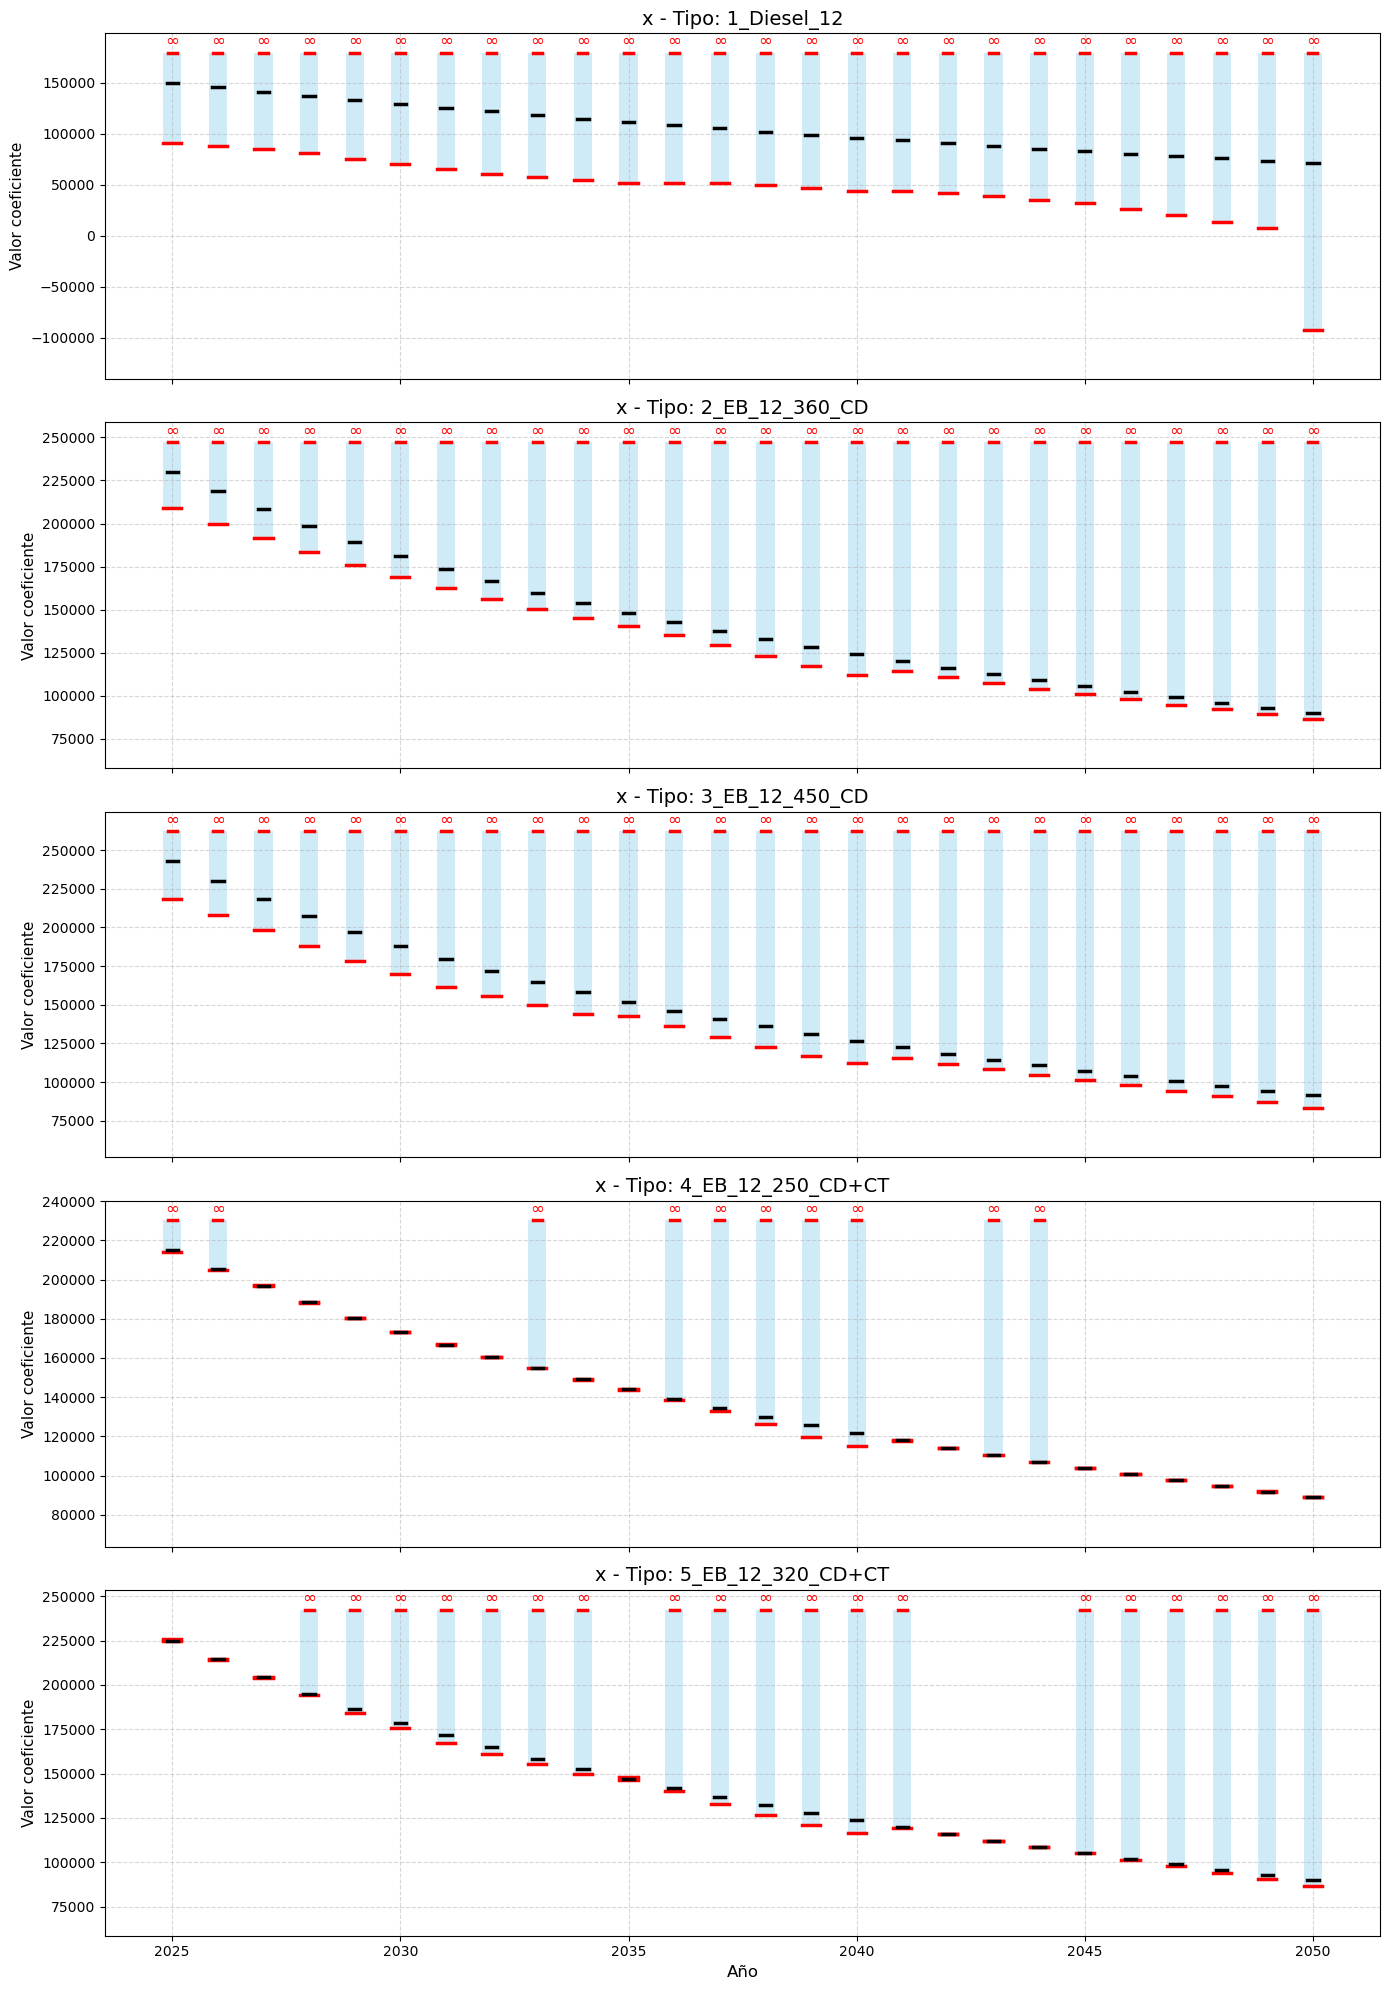

'\n# Extraer y mostrar los rangos de sensibilidad\nfor var in mo.getVars():\n    print(f"{var.VarName}: SAObjLow = {var.SAObjLow}, SAObjUp = {var.SAObjUp}")\n'

In [9]:
# Convertir variables enteras a continuas (sólo para el análisis de sensibilidad)
from gurobipy import GRB

for var in mo.getVars():
    var.VType = GRB.CONTINUOUS
mo.update()
mo.optimize()

x_rango = graficar_sensibilidad_variable_v14(mo, x, 'x', eje_tiempo_idx=1)

'''
# Extraer y mostrar los rangos de sensibilidad
for var in mo.getVars():
    print(f"{var.VarName}: SAObjLow = {var.SAObjLow}, SAObjUp = {var.SAObjUp}")
'''

In [ ]:
for i in x_rango:
    print(f"Variable: {i}, Rango: {x_rango[i]}, Valor: {x[i].X}")

In [ ]:
tam_bat('1_Diesel_12',K_E)

In [ ]:
cost_bus_sin_bat['1_Diesel_12']

In [ ]:
x_rango[('1_Diesel_12', 2025)][0][1] - cost_bus_sin_bat['1_Diesel_12']

In [10]:
def int_costo_kwh(a,t,k,beta,cost_bus_sin_bat,K_E,T):
    trans_T = {j: i for i,j in enumerate(T)}
    """
    Función para calcular el costo del kWh en función de los parámetros de entrada.
    """
    # Calcular el costo del kWh
    if k in K_E:
        costo_kwh = ( ( a / ( beta**( (trans_T[t]+1) -1)  ) ) - cost_bus_sin_bat[k] ) / tam_bat(k,K_E)
    else:
        costo_kwh = a
    return costo_kwh

In [11]:
x_rango2 = {(k,t): [ (int_costo_kwh(j[0][0],t,k,beta,cost_bus_sin_bat,K_E,T),int_costo_kwh(j[0][1],t,k,beta,cost_bus_sin_bat,K_E,T) ) , int_costo_kwh(j[1],t,k,beta,cost_bus_sin_bat,K_E,T) ] for (k,t),j in x_rango.items()}


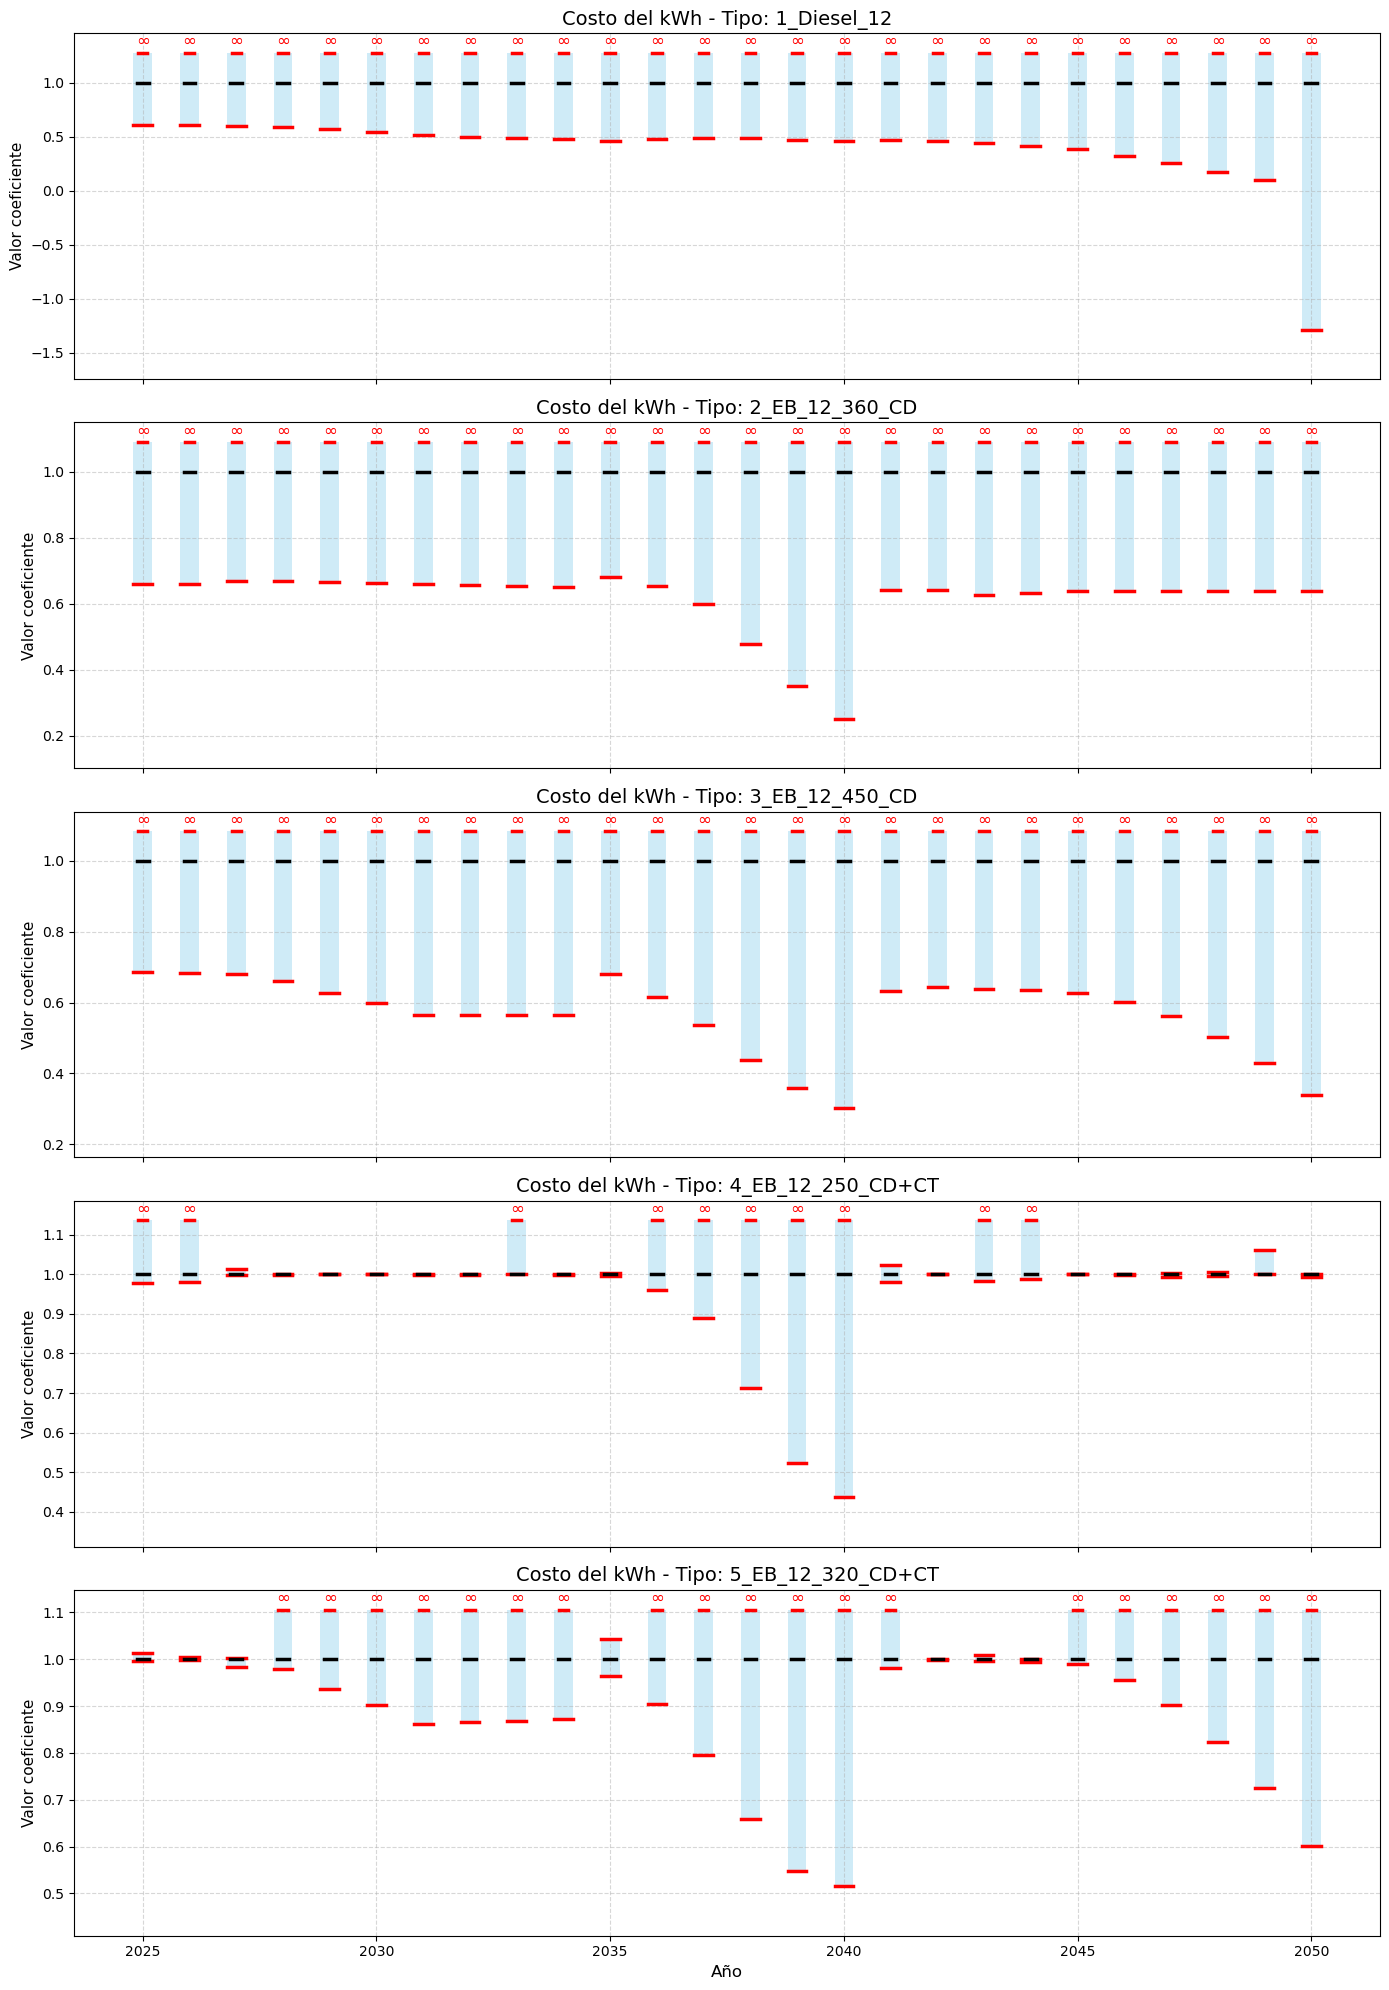

{}

In [19]:
graficar_sensibilidad_costo_kwh(x_rango2, 'Costo del kWh', eje_tiempo_idx=1,porcen = True)

In [17]:
for i in x_rango2.keys():
    if '320' in i[0]:
        print(f"Variable: {i}, Rango: {x_rango2[i][0]}, Valor: {x_rango2[i][1]}")
        print(f"Rango: {x_rango2[i][0][1] - x_rango2[i][0][0]}")  # Diferencia entre los límites del rango

Variable: ('5_EB_12_320_CD+CT', 2025), Rango: (172.31193354750184, 175.39179147607965), Valor: 173.0
Rango: 3.079857928577809
Variable: ('5_EB_12_320_CD+CT', 2026), Rango: (159.68122981914604, 160.70870844607316), Valor: 160.0
Rango: 1.0274786269271203
Variable: ('5_EB_12_320_CD+CT', 2027), Rango: (145.59365969196406, 148.32078116053907), Valor: 148.00000000000009
Rango: 2.7271214685750067
Variable: ('5_EB_12_320_CD+CT', 2028), Rango: (133.1290783109789, inf), Valor: 136.0
Rango: inf
Variable: ('5_EB_12_320_CD+CT', 2029), Rango: (118.03800333175995, inf), Valor: 126.0
Rango: inf
Variable: ('5_EB_12_320_CD+CT', 2030), Rango: (105.61769546935557, inf), Valor: 117.0
Rango: inf
Variable: ('5_EB_12_320_CD+CT', 2031), Rango: (94.7534806511555, inf), Valor: 110.0
Rango: inf
Variable: ('5_EB_12_320_CD+CT', 2032), Rango: (89.27408252935057, inf), Valor: 103.0
Rango: inf
Variable: ('5_EB_12_320_CD+CT', 2033), Rango: (84.13922330334063, inf), Valor: 97.0
Rango: inf
Variable: ('5_EB_12_320_CD+CT',

In [ ]:
graficar_sensibilidad_variable_v14(mo, u, 'u', eje_tiempo_idx=1)

In [ ]:
graficar_sensibilidad_variable_v14(mo, u_tilde, 'u_tilde', eje_tiempo_idx=1)

In [ ]:
for idx, var in u_tilde.items():
    print(idx, var.Obj, var.SAObjLow, var.SAObjUp)

In [ ]:
x

In [ ]:
'''
informacion = {}

info_exportar = exportar_solucion(x,z,y,u,u_tilde,v,v_tilde,w,b,K,T,J_K,CT,R,f,p,o,F,g,mo,kappa,alpha,beta,num_per,p_tilde,K_E,J_K_tilde,t_F,s,mc,var_epsilon,Theta,Theta_tilde,L,params_exp)
informacion['Escenario {}'.format(i)] = info_exportar
del L,CT,T,K,J_K,J_K_tilde,K_E,C,alpha,R,beta,f,s,kappa,mc,p,F,g,p_tilde,num_per,o,q,h,t1,a,e,e_tilde,t_F,Gamma,theta,theta_tilde,B,Theta,Theta_tilde,var_epsilon,c_tilde
del mo,x,y,z,w,u,v,b,u_tilde,v_tilde,sol_salida
del info_exportar, params_exp
'''

In [13]:
from modulo_graficos import graficar_un_escenario, graficar_emisiones_por_contaminante, graficar_inversion_acumulada_por_escenario, graficar_costos_por_tipo, graficar_un_escenario_cargadores_contenedores

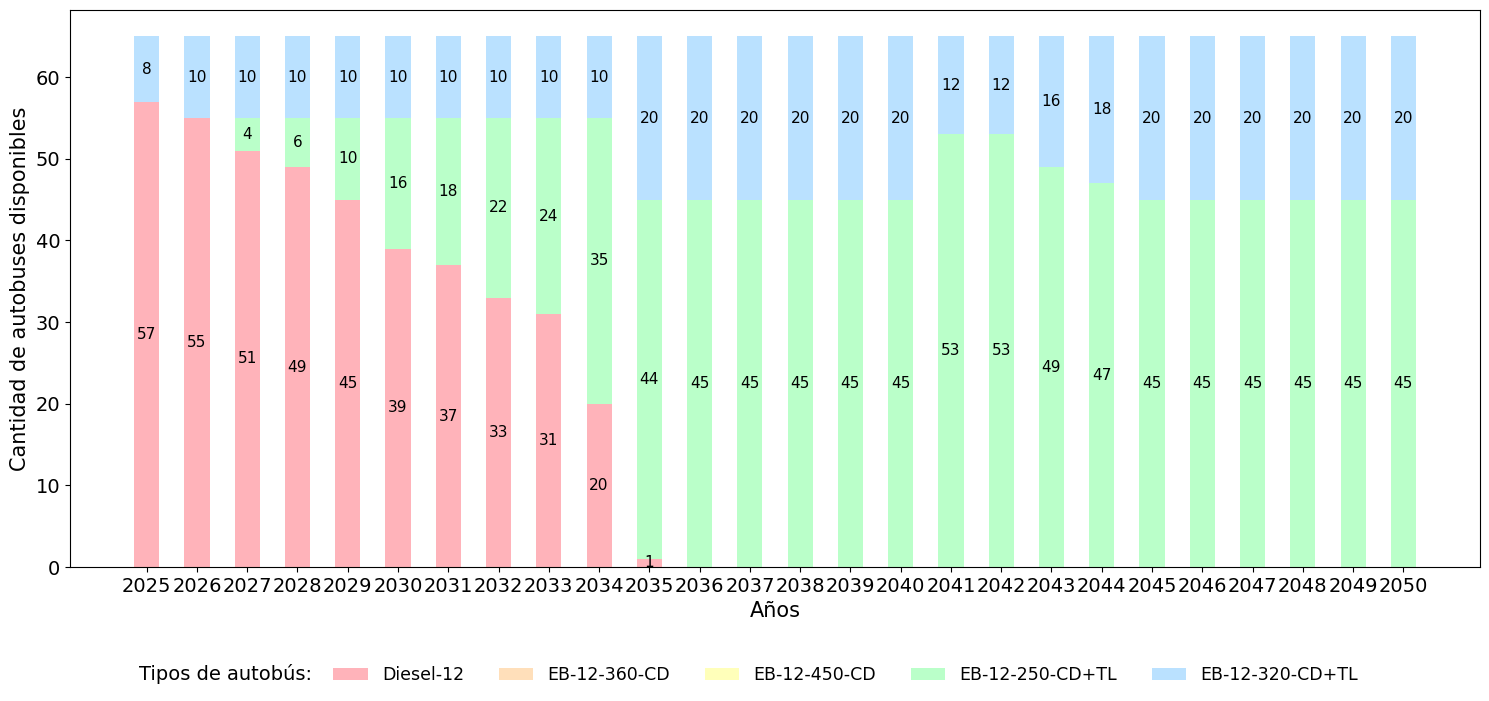

In [14]:
graficar_un_escenario(informacion, 'Autobuses Disponibles', 'Escenario 0', list(range(2025,2051)))

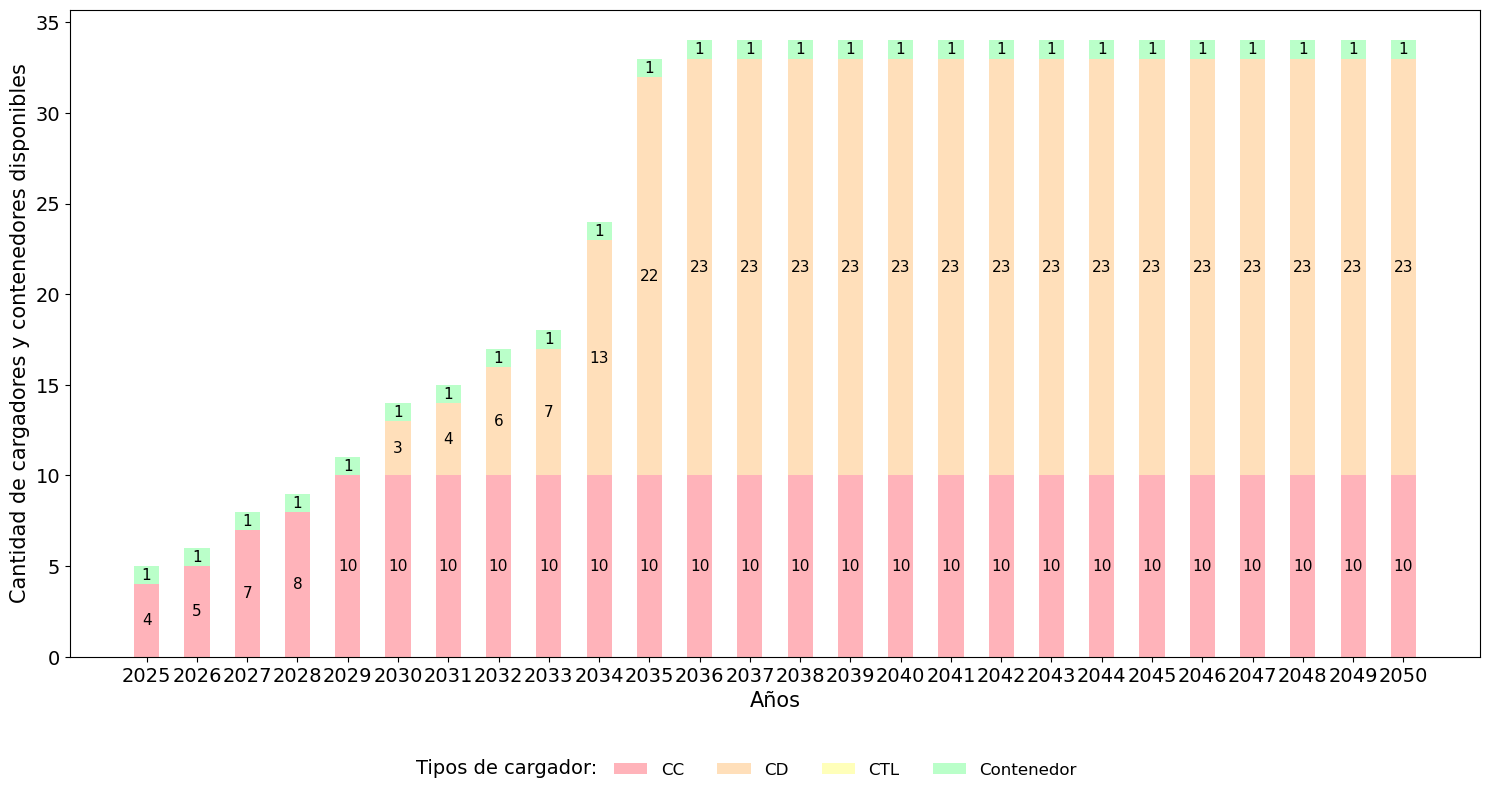

In [15]:
graficar_un_escenario_cargadores_contenedores(informacion, 'Cargadores Disponibles', 'Contenedores Disponibles', 'Escenario 0', list(range(2025,2051)))

In [ ]:
'''
escenarios_0_10_11 = {i:j for i,j in informacion.items() if int(i.split(' ')[1]) in [0,10,11]}
escenarios_sin_10_11 = {i:j for i,j in informacion.items() if int(i.split(' ')[1]) not in [10,11]}
graficar_un_escenario(informacion, 'Autobuses Disponibles', 'Escenario 0', [2025,2026,2027,2028,2029])
graficar_un_escenario_cargadores_contenedores(informacion, 'Cargadores Disponibles', 'Contenedores Disponibles', 'Escenario 0', [2025,2026,2027,2028,2029])
graficar_autobuses_por_tipo_varios_anios_subplots(escenarios_sin_10_11, 'Autobuses Disponibles', [2025,2026,2027,2028,2029])
graficar_autobuses_por_tipo_varios_anios_subplots(escenarios_0_10_11, 'Autobuses Disponibles', list(range(2025,2035)))
graficar_inversion_acumulada_por_escenario(escenarios_0_10_11, 'Inversion')
graficar_inversion_acumulada_por_escenario(escenarios_sin_10_11, 'Inversion')
graficar_cargadores_y_contenedores_por_tipo_varios_anios_subplots(escenarios_sin_10_11, 'Cargadores Disponibles', 'Contenedores Disponibles', [2025, 2026, 2027, 2028, 2029])
graficar_cargadores_y_contenedores_por_tipo_varios_anios_subplots(escenarios_0_10_11, 'Cargadores Disponibles', 'Contenedores Disponibles', list(range(2025,2035)))
graficar_costos_por_tipo(informacion, 'Resumen')
graficar_emisiones_por_contaminante(escenarios_sin_10_11, 'Emisiones', 'SO2')
graficar_emisiones_por_contaminante(escenarios_sin_10_11, 'Emisiones', 'PM25')
graficar_emisiones_por_contaminante(escenarios_sin_10_11, 'Emisiones', 'NOX')
graficar_asignacion_autobuses_por_ruta(informacion, 'Autobuses electricos por ruta')
''';

In [ ]:
graficar_emisiones_por_contaminante(informacion, 'Emisiones', 'SO2')

In [ ]:
graficar_inversion_acumulada_por_escenario(informacion, 'Inversion')

In [ ]:
graficar_costos_por_tipo(informacion, 'Resumen')

In [ ]:
model = mo

In [ ]:

# Maximum number of scenarios to be considered
maxScenarios = 100

if model.IsMIP == 0:
    print("Model is not a MIP")

# Solve model
model.optimize()

if model.Status != GRB.OPTIMAL:
    print(f"Optimization ended with status {model.Status}")
    sys.exit(0)

# Store the optimal solution
origObjVal = model.ObjVal
for v in model.getVars():
    v._origX = v.X


scenarios = 0

# Count number of unfixed, binary variables in model. For each we create a
# scenario.
for v in model.getVars():
    if v.LB == 0.0 and v.UB == 1.0 and v.VType in (GRB.BINARY, GRB.INTEGER):
        scenarios += 1

        if scenarios >= maxScenarios:
            break


# Set the number of scenarios in the model
model.NumScenarios = scenarios
scenarios = 0

print(f"###  construct multi-scenario model with {scenarios} scenarios")

# Create a (single) scenario model by iterating through unfixed binary
# variables in the model and create for each of these variables a scenario
# by fixing the variable to 1-X, where X is its value in the computed
# optimal solution
for v in model.getVars():
    if (
        v.LB == 0.0
        and v.UB == 1.0
        and v.VType in (GRB.BINARY, GRB.INTEGER)
        and scenarios < maxScenarios
    ):
        # Set ScenarioNumber parameter to select the corresponding scenario
        # for adjustments
        model.Params.ScenarioNumber = scenarios

        # Set variable to 1-X, where X is its value in the optimal solution
        if v._origX < 0.5:
            v.ScenNLB = 1.0
        else:
            v.ScenNUB = 0.0

        scenarios += 1

    else:
        # Add MIP start for all other variables using the optimal solution
        # of the base model
        v.Start = v._origX


# Solve multi-scenario model
model.optimize()


# In case we solved the scenario model to optimality capture the
# sensitivity information
if model.Status == GRB.OPTIMAL:
    modelSense = model.ModelSense
    scenarios = 0

    # Capture sensitivity information from each scenario
    for v in model.getVars():
        if v.LB == 0.0 and v.UB == 1.0 and v.VType in (GRB.BINARY, GRB.INTEGER):
            # Set scenario parameter to collect the objective value of the
            # corresponding scenario
            model.Params.ScenarioNumber = scenarios

            # Collect objective value and bound for the scenario
            scenarioObjVal = model.ScenNObjVal
            scenarioObjBound = model.ScenNObjBound

            # Check if we found a feasible solution for this scenario
            if modelSense * scenarioObjVal >= GRB.INFINITY:
                # Check if the scenario is infeasible
                if modelSense * scenarioObjBound >= GRB.INFINITY:
                    print(
                        f"Objective sensitivity for variable {v.VarName} is infeasible"
                    )
                else:
                    print(
                        f"Objective sensitivity for variable {v.VarName} is unknown (no solution available)"
                    )
            else:
                # Scenario is feasible and a solution is available
                print(
                    f"Objective sensitivity for variable {v.VarName} is {modelSense * (scenarioObjVal - origObjVal):g}"
                )

            scenarios += 1

            if scenarios >= maxScenarios:
                break